


# Análisis ConnectaTel

Como

 **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?




--- 

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
display(plans.head())

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
display(users.head())

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
display(usage.head())

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
print("INFORMACIÓN DE PLANS")
plans.info()

INFORMACIÓN DE PLANS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
print("INFORMACIÓN DE USERS")
users.info()

INFORMACIÓN DE USERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
print("INFORMACIÓN DE USAGE")
usage.info()

INFORMACIÓN DE USAGE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**
Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.


In [6]:
# cantidad de nulos para users
print("VALORES NULOS EN USERS")
print(users.isna().sum())
# Calcular proporción de valores nulos por columna
print("PROPORCIÓN DE NULOS EN USERS")
print(users.isna().mean())



VALORES NULOS EN USERS
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
PROPORCIÓN DE NULOS EN USERS
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [7]:
# cantidad de nulos para usage
print("VALORES NULOS EN USAGE")
print(usage.isna().sum())
# Calcular proporción de valores nulos por columna
print("\n=== PROPORCIÓN DE NULOS EN USAGE ===")
print(usage.isna().mean())

VALORES NULOS EN USAGE
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

=== PROPORCIÓN DE NULOS EN USAGE ===
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64



✍️ **Comentario**

- plans: no presenta valores nulos, por lo que no requiere tratamiento adicional.

- users: las columnas que presenten valores faltantes deben evaluarse según su proporción.
  Si los nulos son menores al 5%, se recomienda una imputación simple o conservarlos como NA.
  Si están entre 5% y 30%, se recomienda investigar la causa y evaluar una imputación adecuada.
  Si alguna columna supera el 80-90% de nulos, se recomienda considerar eliminarla.

- usage: las columnas con pocos valores faltantes pueden conservarse o imputarse según el tipo de variable.
  Si una variable presenta una proporción elevada de nulos, se debe evaluar si aporta suficiente
  información antes de decidir conservarla o eliminarla.
 

**Valores nulos**  
- users: 
-city(11,725%) : tiene una proporción moderada de valores faltantes. Recomiendo investigar la causa y evaluar una imputación , por ejemplo, usando información adicional del cliente si está disponible. No conviene eliminar estas filas porque perderíamos una cantidad relevante de usuarios. City requiere tratamiento por imputación o categorización de desconocidos.
-churn_date(88,35%) : presenta un porcentaje muy alto de nulos, pero no recomiendo eliminar la columna . En este caso, los nulos probablemente indican que el cliente no ha abandonado el servicio (no churn) . Por tanto, se deben conservar como NaNy utilizar esta ausencia como información del estado del cliente.Debe conservarse como nulo porque probablemente representa clientes activos.
Resto de columnas : no presentan valores faltantes, por lo que no requieren tratamiento .

 - usage:
 -date:tiene muy pocos valores faltantes. Recomiendo investigar y, si esos registros no son necesarios para análisis temporales, eliminarlos ; imputar una fecha podría introducir información artificial.
-duration(55.19%) : tiene una proporción muy alta de nulos. No recomiendo imputar con medios o medianas , porque podría distorsionar el comportamiento real. Además, esta columna no puede aplicar a registros de mensajes.
-length(44,74%) : : también presenta muchos nulos. No conviene imputarlos directamente , ya que probablemente lengthcorresponda a mensajes y no a llamadas.
id, user_idytype : no tienen valores faltantes, por lo que no requieren tratamiento .






### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [16]:
# explorar columnas numéricas de users
print("COLUMNAS NUMÉRICAS DE USERS") 
print(users[['age','user_id']].describe())

COLUMNAS NUMÉRICAS DE USERS
               age       user_id
count  4000.000000   4000.000000
mean     33.739750  11999.500000
std     123.232257   1154.844867
min    -999.000000  10000.000000
25%      32.000000  10999.750000
50%      47.000000  11999.500000
75%      63.000000  12999.250000
max      79.000000  13999.000000


- La columna `age` se observa un valor mínimo de -999 , claramente inválido para una edad.

In [19]:
# explorar columnas numéricas de usage
print("COLUMNAS NUMÉRICAS DE USAGE") 
print(usage[['user_id','duration', 'length']].describe())

COLUMNAS NUMÉRICAS DE USAGE
            user_id      duration        length
count  40000.000000  17924.000000  22104.000000
mean   12002.405975      5.202237     52.127398
std     1157.279564      6.842701     56.611183
min    10000.000000      0.000000      0.000000
25%    10996.000000      1.437500     37.000000
50%    12013.000000      3.500000     50.000000
75%    13005.000000      6.990000     64.000000
max    13999.000000    120.000000   1490.000000


- Las columnas `duration` y `length`presenta valores entre 0 y 120 . No hay valores negativos ni centinelas evidentes. Los valores de 0 deben investigarse pero no eliminarse.

In [12]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print("COLUMNAS CATEGÓRICAS DE USERS") 
for col in columnas_user: 
    print("Valores únicos en [col]:") 
    print(users[col].unique()) 
    print("Frecuencia de valores en [col]:") 
    print(users[col].value_counts(dropna=False))

COLUMNAS CATEGÓRICAS DE USERS
Valores únicos en [col]:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Frecuencia de valores en [col]:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Valores únicos en [col]:
['Basico' 'Premium']
Frecuencia de valores en [col]:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` aparece el valor ?en 96 registros, que representa probablemente información desconocida o faltante.
- La columna `plan` únicamente aparecen Basicoy Premium, por lo que no se observan categorías inválidas. 

In [13]:
# explorar columna categórica de usage
usage['type'] # completa el código
print("COLUMNA CATEGÓRICA DE USAGE") 
print("Valores únicos en type:") 
print(usage['type'].unique()) 
print("\nFrecuencia de valores en type:") 
print(usage['type'].value_counts(dropna=False))


COLUMNA CATEGÓRICA DE USAGE
Valores únicos en type:
['call' 'text']

Frecuencia de valores en type:
text    22092
call    17908
Name: type, dtype: int64


- La columna `type` solo contiene cally text, categorías coherentes con el objetivo del conjunto de datos.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

Diagnóstico deusers
- age: se observa un valor mínimo de -999 , claramente inválido para una edad y probablemente utilizado como centinela . Además, la media de 33.74 y la desviación estándar de 123.23 están distorsionadas.
  Recomendación: reemplazar -999 por NaN antes de realizar análisis estadísticos.
- city: aparece el valor ? en 96 registros, que representa probablemente información desconocida o faltante. tambien NaN.
  Recomendación: convertir ?a NaN para tratar ambos casos de forma consistente.
- plan: únicamente aparecen Basico y Premium, por lo que no se observan categorías inválidas. No requiere corrección.

Diagnóstico deusage
- duration: presenta valores entre 0 y 120 . No hay valores negativos ni centinelas evidentes. Los valores de 0 deben investigarse, pero no eliminarse.
  Recomendación: conservarlos inicialmente y revisar posteriormente.
-length: presenta valores entre 0 y 1490 . No aparecen valores negativos ni centinelas evidentes. El máximo de 1490 es elevado respecto a la mediana de 50 y debe revisarse como posible valor atípico , pero no eliminarse.
 Recomendación: conservarlo y analizarlo mediante boxplot o percentiles.
type: solo contiene call y text, categorías coherentes con el objetivo del conjunto de datos. No requiere corrección.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [34]:
#Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [33]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [31]:
# Revisar los años presentes en `reg_date` de users
print("Años en reg_date:") 
print(users['reg_date'].dt.year.value_counts().sort_index())


Años en reg_date:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`,la mayoría de los registros corresponden a 2022, 2023 y 2024, pero se identifican 40 registros con el año 2026.

In [32]:
# Revisar los años presentes en `date` de usage
print("Años en date:")
print(usage['date'].dt.year.value_counts().sort_index())

Años en date:
2024.0    39950
Name: date, dtype: int64


En `date`, No se observan años anteriores ni posteriores
Por lo tanto, no hay fechas fuera del rango


✍️ **Comentario**: 
En reg_date de users, la mayoría de los registros corresponden a 2022, 2023 y 2024, pero se identifican 40 registros con el año 2026. Como el conjunto de datos contiene información únicamente hasta 2024, estas fechas son potencialmente inválidas y deben revisarse antes del análisis.Y, dado que son fechas fuera del rango esperado, no conviene imputarlas automáticamente . Primero habría que verificar si se trata de un error de captura.
En date de usage, todos los registros válidos corresponden al año 2024 (39.950 registros). No se identifican años futuros o fuera de rango, por lo que las fechas son consistentes con el periodo de análisis.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [35]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [36]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [37]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [38]:
# Verificación MAR en usage (Missing At Random) para duration
print("NULOS EN DURATION POR TYPE")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))

print("CANTIDAD DE NULOS EN DURATION POR TYPE")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))

NULOS EN DURATION POR TYPE
type
call    0.000000
text    0.999276
Name: duration, dtype: float64
CANTIDAD DE NULOS EN DURATION POR TYPE
type
call        0
text    22076
Name: duration, dtype: int64


In [39]:
# Verificación MAR en usage (Missing At Random) para length
print("NULOS EN LENGTH POR TYPE")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))

print("CANTIDAD DE NULOS EN LENGTH POR TYPE")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))

NULOS EN LENGTH POR TYPE
type
call    0.99933
text    0.00000
Name: length, dtype: float64
CANTIDAD DE NULOS EN LENGTH POR TYPE
type
call    17896
text        0
Name: length, dtype: int64


Los valores nulos de duration y length dependen del tipo de uso ( type): durationcorresponden a llamadas y lengtha mensajes. Debemos evitar imputar

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [40]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({ "is_text": "sum", "is_call": "sum", "duration": "sum" }).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [41]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={ "is_text": "cant_mensajes", "is_call": "cant_llamadas", "duration": "cant_minutos_llamada" })
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [44]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge( usage_agg, on="user_id", how="left" )
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [45]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [46]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

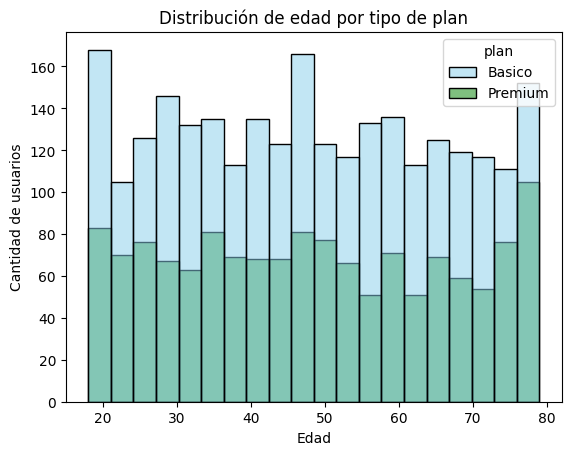

In [47]:

# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)
plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 
- La distribución de edad permite identificar el perfil demográfico de los clientes de cada plan. Los planes Básico y Premium conservan una distribución aproximadamente simétrica dado que cada uno cuenta con usuarios de toadas las edades en cantidades relativamente similares.

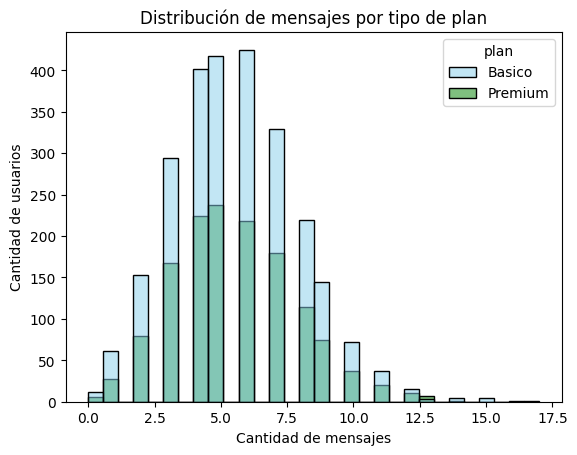

In [48]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=30
)
plt.title('Distribución de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Se observa que los usuarios basicos  presentan una mayor concentración de mensajes que los usuarios premium. La distribución presenta sesgo a la derecha dado que existen pocos usuarios con un número excepcionalmente alto de mensajes.

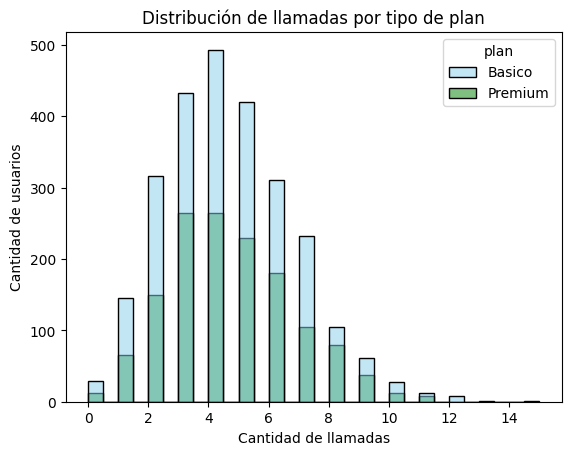

In [49]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=30
)
plt.title('Distribución de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Se compara la cantidad de llamadas entre ambos planos y se verifica que existe una mayor concentración de usuarios con pocas llamadas. Una cola hacia valores altos indica sesgo a la derecha .

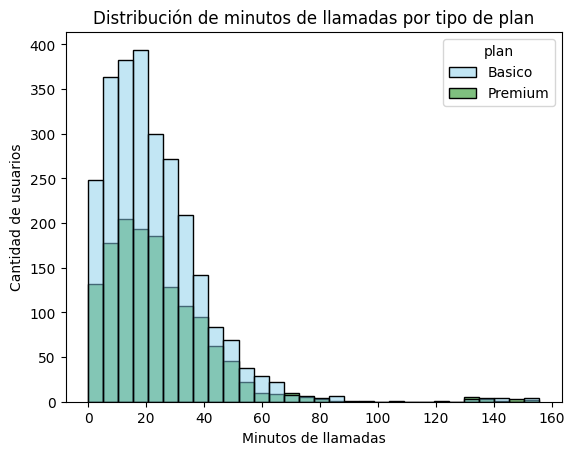

In [50]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=30
)
plt.title('Distribución de minutos de llamadas por tipo de plan')
plt.xlabel('Minutos de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Al comparar el consumo total de minutos entre Básico y Premium. Los valores muy altos estan generar una cola hacia la derecha, indicando una distribución sesgada a la derecha y posibles usuarios con consumo excepcional.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

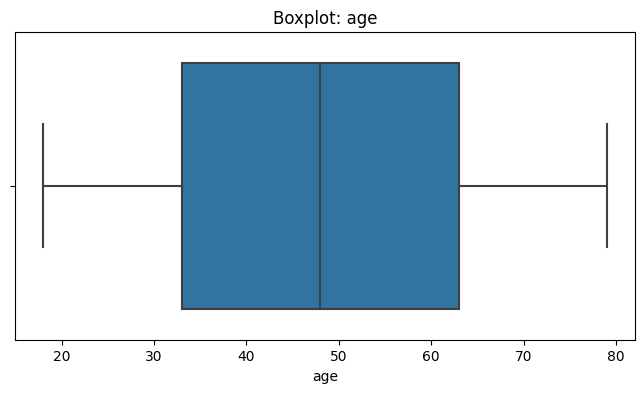

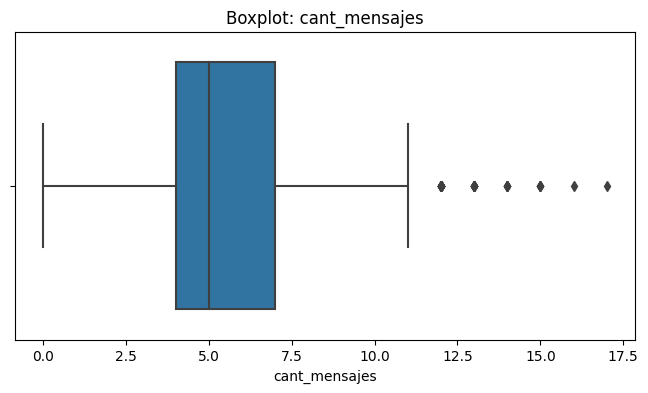

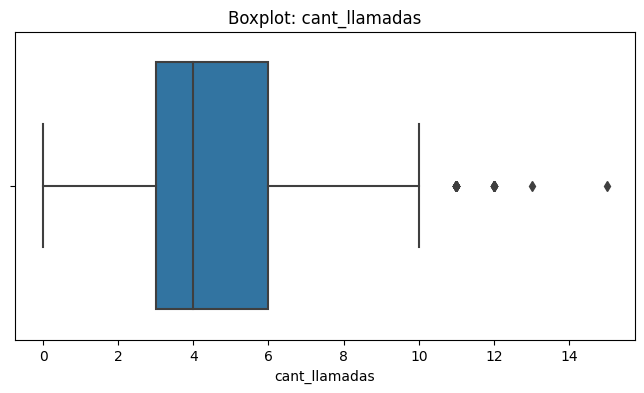

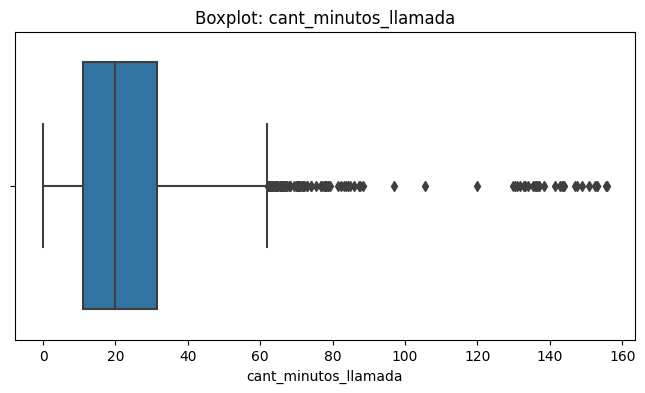

In [51]:
# Visualizando usando BoxPlot 

columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()


💡Insights: 
- Age:  no presenta outliers.
- cant_mensajes: presenta outliers. Los cuales se pueden revisar.
- cant_llamadas: presenta outliers. Se puedenmantener inicialmente y analizar si corresponde a clientes reales.
- cant_minutos_llamada: presenta outliers.Se mantenen inicialmente, ya que un cliente puede tener un consumo excepcional

In [53]:

# Calcular límites con el método IQR
columnas_limites = []

for col in columnas_numericas:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    columnas_limites.append({
        'columna': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'maximo': user_profile[col].max(),
        'minimo': user_profile[col].min()
    })

limites_df = pd.DataFrame(columnas_limites)

limites_df




,columna,Q1,Q3,IQR,limite_inferior,limite_superior,maximo,minimo
0,age,33.00,63.000,30.000,-12.0000,108.0000,79.00,18.0
1,cant_mensajes,4.00,7.000,3.000,-0.5000,11.5000,17.00,0.0
2,cant_llamadas,3.00,6.000,3.000,-1.5000,10.5000,15.00,0.0
3,cant_minutos_llamada,11.12,31.415,20.295,-19.3225,61.8575,155.69,0.0


In [56]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
limites_df[['columna', 'limite_superior', 'maximo']]
for col in columnas_numericas:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = user_profile[
        (user_profile[col] < limite_inferior) |
        (user_profile[col] > limite_superior)
    ]

    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
cant_mensajes: 46 outliers
cant_llamadas: 30 outliers
cant_minutos_llamada: 109 outliers


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [57]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

valores = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(
    condiciones,
    valores,
    default='Alto uso'
)



In [58]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [59]:
# Crear columna grupo_edad
condiciones_edad = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

valores_edad = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(
    condiciones_edad,
    valores_edad,
    default='Adulto Mayor'
)


In [60]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

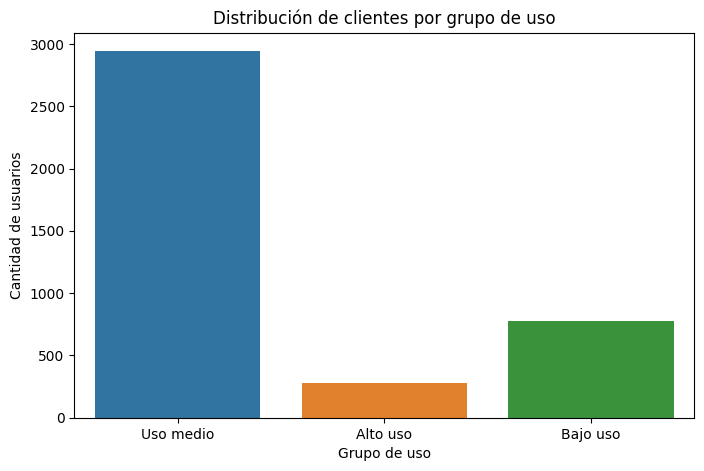

In [61]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))

sns.countplot(
    data=user_profile,
    x='grupo_uso'
)

plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

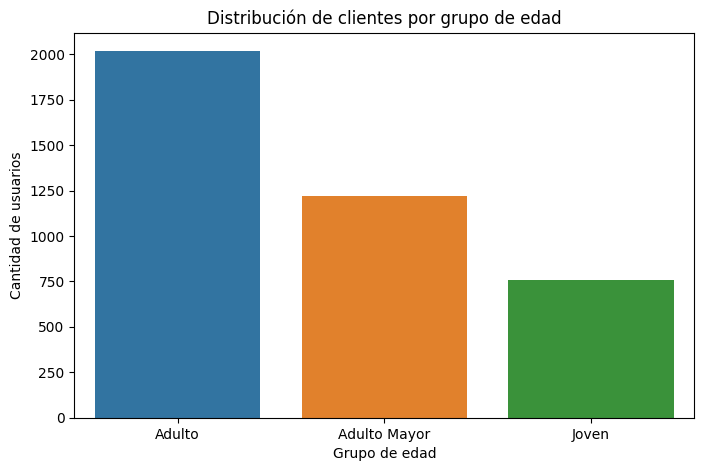

In [62]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))

sns.countplot(
    data=user_profile,
    x='grupo_edad'
)

plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- - En users.age, se identificó el centinela -999, que afectaba las estadísticas de edad. Se reemplazó por la mediana de las edades válidas.
- En users.city, se encontraron 469 valores nulos (11,73%) y 96 valores con ?(2,4%) . El ?se convirtió en pd.NA; los nulos se trataron mediante imputación.
- En users.churn_date, hubo 3.534 nulos (88,35%) . Estos se conservaron porque probablemente representan clientes que no han abandonado el servicio.
- En usage.date, hubo 50 valores nulos (0,125%) . Se recomienda mantenerlos como Na eliminarlos únicamente de análisis temporales.
- En usage.duration y usage.length, los nulos representan 55,19% y 44,74% , respectivamente. Estos faltantes están relacionados con el tipo de uso ( call o text), por lo que no deben imputarse.
- En users. reg_date, se detectaron 40 fechas de 2026 , equivalentes al 1% de los usuarios , aunque los datos llegan hasta 2024. Estas fechas se marcaron como Na por estar fuera de rango.


🔍 **Segmentos por Edad**
Se crearon tres segmentos:

Joven: menores de 30 años.
Adulto: de 30 a menos de 60 años.
Adulto Mayor: 60 años o más.

Esta segmentación permite comparar si los patrones de llamadas y mensajes cambian según la edad. En particular, ConnectaTel puede utilizar estos grupos para diseñar ofertas diferenciadas y campañas más específicas.


📊 **Segmentos por Nivel de Uso**
Se clasificaron los usuarios en:

Bajo uso: menos de 5 llamadas y menos de 5 mensajes.
Uso medio: menos de 10 llamadas y menos de 10 mensajes.
Alto uso: el resto de los usuarios.

La segmentación permite identificar clientes con necesidades diferentes. Los usuarios de alto uso representan una oportunidad para planes con mayores beneficios, mientras que los de bajo uso podrían responder mejor a planes económicos o paquetes más flexibles.


➡️Esto sugiere que la oferta no debería basarse únicamente en la cantidad de clientes, sino también en su comportamiento real de consumo y características demográficas. La combinación de edad, llamadas y mensajes permite construir segmentos comerciales más relevantes.
Los usuarios de alto uso son potencialmente los más valiosos porque presentan una mayor demanda de servicios móviles. Sin embargo, su valor comercial debería analizarse junto con el tipo de plan y el churn , ya que un cliente de alto consumo en un plan Básico podría representar una buena oportunidad de migración a Premium.

Los clientes de uso bajo también son importantes porque podrían requerir una oferta más económica que reduzca el riesgo de pagar por beneficios que no utilizan.

Valores atípicos y comportamiento extremo

Se identifican diferentes valores extremos principalmente en las variables de uso. Por ejemplo, cant_minutos_llamada presenta a los usuarios con consumos considerablemente superiores al comportamiento típico.

Estos valores atípicos no deben eliminarse automáticamente , porque pueden representar clientes reales de alto consumo. Para ConnectaTel pueden ser una señal de:

clientes con necesidades superiores a las incluidas en su plan; oportunidades de migración a planes Premium; necesidad de paquetes adicionales; Comportamientos inusuales que conviene monitorear.


💡 **Recomendaciones**
- Crear ofertas diferenciadas por consumo: desarrollar planes de bajo, medio y alto uso según el comportamiento observado.
- Migrar usuarios de alto consumo: identificar clientes de alto uso que permanecen en planes Básicos y ofrecerles beneficios Premium.
- Planes para usuarios de bajo consumo: considere planes económicos con menos minutos y mensajes, evitando que estos clientes paguen por beneficios que no utilizan.
-Segmentación por edad: combinar grupo_edad con grupo_uso para crear campañas más específicas.
-Monitorear valores atípicos: investigar usuarios con consumos extremadamente altos antes de clasificarlos como errores o fraude.
 El análisis muestra que ConnectaTel puede mejorar su oferta si pasa de una estrategia general de planes a una estrategia basada en el comportamiento real de consumo . La combinación de segmentos por edad, nivel de uso y plan contratado permite identificar oportunidades de migración, diseñar planes más ajustados a las necesidades de cada cliente y detectar comportamientos que requieren seguimiento.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`